In [54]:
#!/mrhome/amingk/anaconda3/envs/7tpd/bin/python
import numpy as np
import pandas as pd
import stan
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('/mrhome/amingk/Documents/7TPD/ActStimRL')
import arviz as az
from scipy.stats import gaussian_kde
from utils import *
import os
from scipy.stats import pearsonr
from scipy import stats

In [55]:
# read behavioral data with summary paramter
df_beh_paramerer = pd.read_csv(PROJECT_NoNAN_BEH_REL_IRREL_HIGH_REWARD_OPTION_GROUPBY_ALL_FILE_MODEL_PARAMETER)
# drop group column 
df_beh_paramerer.drop('group', axis=1, inplace=True)
# Read clinical data
clinical_evaluation = pd.read_csv(f'{PROJECT_CLIN_EVAL_FILE}')

In [60]:
# Split clinical data
clinical_evaluation_PD = clinical_evaluation[clinical_evaluation['patient'] == 'PD']
clinical_evaluation_HC = clinical_evaluation[clinical_evaluation['patient'] == 'HC']
# PD wih OFF and ON
clinical_evaluation_PD_OFF = clinical_evaluation_PD.drop(['most_affected_left_right_side_UPDRSON', 'total_UPDRSON'], axis=1)
clinical_evaluation_PD_ON = clinical_evaluation_PD.drop(['most_affected_left_right_side_UPDRSOFF', 'total_UPDRSOFF'], axis=1)

# rename of columns in HC
clinical_evaluation_HC = clinical_evaluation_HC.drop(['most_affected_left_right_side_UPDRSOFF', 'total_UPDRSOFF'], axis=1)
clinical_evaluation_HC.rename(columns={'most_affected_left_right_side_UPDRSON':'most_affected_left_right_side_UPDRS',
                                       'total_UPDRSON':'total_UPDRS'}, inplace=True)
# rename of columns in PD
clinical_evaluation_PD_ON.rename(columns={'most_affected_left_right_side_UPDRSON':'most_affected_left_right_side_UPDRS',
                                          'total_UPDRSON':'total_UPDRS'}, inplace=True)
clinical_evaluation_PD_OFF.rename(columns={'most_affected_left_right_side_UPDRSOFF':'most_affected_left_right_side_UPDRS',
                                           'total_UPDRSOFF':'total_UPDRS'}, inplace=True)


# Filter behavioral data
df_PD_Act_OFF = df_beh_paramerer[
    (df_beh_paramerer['patient'] == 'PD') &
    (df_beh_paramerer['block'] == 'Act') &
    (df_beh_paramerer['medication'] == 'OFF')]

df_PD_Stim_OFF = df_beh_paramerer[
    (df_beh_paramerer['patient'] == 'PD') &
    (df_beh_paramerer['block'] == 'Stim') &
    (df_beh_paramerer['medication'] == 'OFF')]

df_PD_Act_ON = df_beh_paramerer[
    (df_beh_paramerer['patient'] == 'PD') &
    (df_beh_paramerer['block'] == 'Act') &
    (df_beh_paramerer['medication'] == 'ON')]

df_PD_Stim_ON = df_beh_paramerer[
    (df_beh_paramerer['patient'] == 'PD') &
    (df_beh_paramerer['block'] == 'Stim') &
    (df_beh_paramerer['medication'] == 'ON')]

df_HC_Act = df_beh_paramerer[
    (df_beh_paramerer['patient'] == 'HC') &
    (df_beh_paramerer['block'] == 'Act')]

df_HC_Stim = df_beh_paramerer[
    (df_beh_paramerer['patient'] == 'HC') &
    (df_beh_paramerer['block'] == 'Stim')]

# Merge behavioral + clinical
merged_HC_Act = pd.merge(df_HC_Act, clinical_evaluation_HC, on=['sub_ID','patient'], how='inner')
merged_HC_Stim = pd.merge(df_HC_Stim, clinical_evaluation_HC, on=['sub_ID','patient'], how='inner')

merged_PD_Act_OFF = pd.merge(df_PD_Act_OFF, clinical_evaluation_PD_OFF, on=['sub_ID','patient'], how='inner')
merged_PD_Stim_OFF = pd.merge(df_PD_Stim_OFF, clinical_evaluation_PD_OFF, on=['sub_ID','patient'], how='inner')

merged_PD_Act_ON = pd.merge(df_PD_Act_ON, clinical_evaluation_PD_ON, on=['sub_ID','patient'], how='inner')
merged_PD_Stim_ON = pd.merge(df_PD_Stim_ON, clinical_evaluation_PD_ON, on=['sub_ID','patient'], how='inner')

# Concatenate all
df_all = pd.concat([
    merged_HC_Act,
    merged_HC_Stim,
    merged_PD_Act_OFF,
    merged_PD_Stim_OFF,
    merged_PD_Act_ON,
    merged_PD_Stim_ON
], ignore_index=True)

# save in csv 
df_all.to_csv(f'{PROJECT_CLIN_EVAL_PARAM_FILE}', index=False )

Text(0, 0.5, 'BDI')

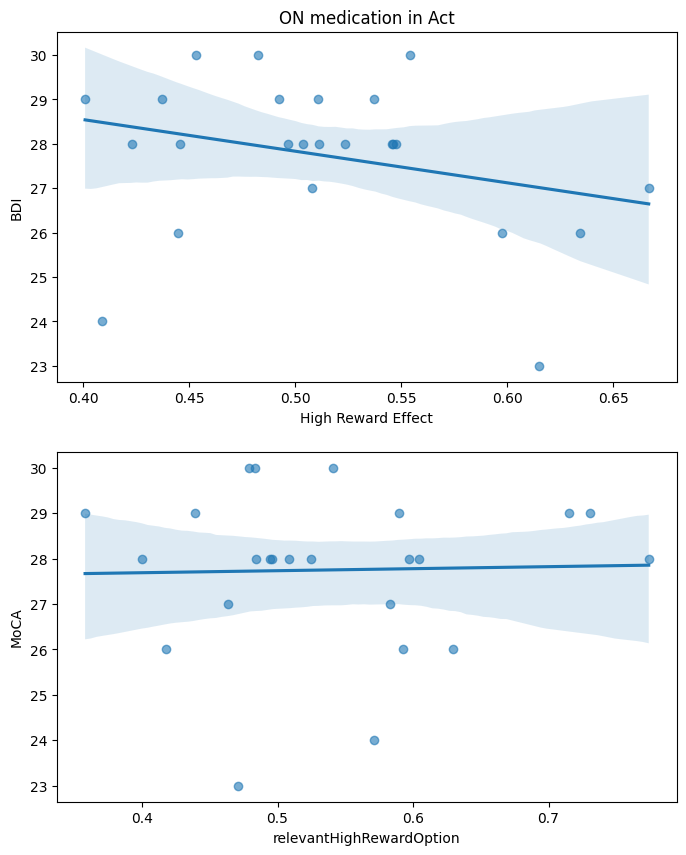

In [111]:

# Plot
fig, ax = plt.subplots(2, 1, figsize=(8, 10))
ax=ax.flatten()
sns.regplot(data=df_all[(df_all['block'] == 'Act')& (df_all['patient'] == 'PD')& (df_all['medication'] == 'OFF')],x="irrelevantHighRewardOption",y="MoCA",
            ax=ax[0],scatter_kws={"alpha": 0.6})
sns.regplot(data=df_all[(df_all['block'] == 'Act')& (df_all['patient'] == 'PD')& (df_all['medication'] == 'OFF')],x="relevantHighRewardOption",y="MoCA",
            ax=ax[1],scatter_kws={"alpha": 0.6})
#sns.regplot(data=df_all[(df_all['block'] == 'Act')& (df_all['patient'] == 'PD')& (df_all['medication'] == 'OFF')],x="relevantVrIrrelevantHighRewardOption",y="BDI",
#            ax=ax,scatter_kws={"alpha": 0.6})
ax[0].set_title("ON medication in Act")
ax[0].set_xlabel("High Reward Effect")
ax[0].set_ylabel("BDI")

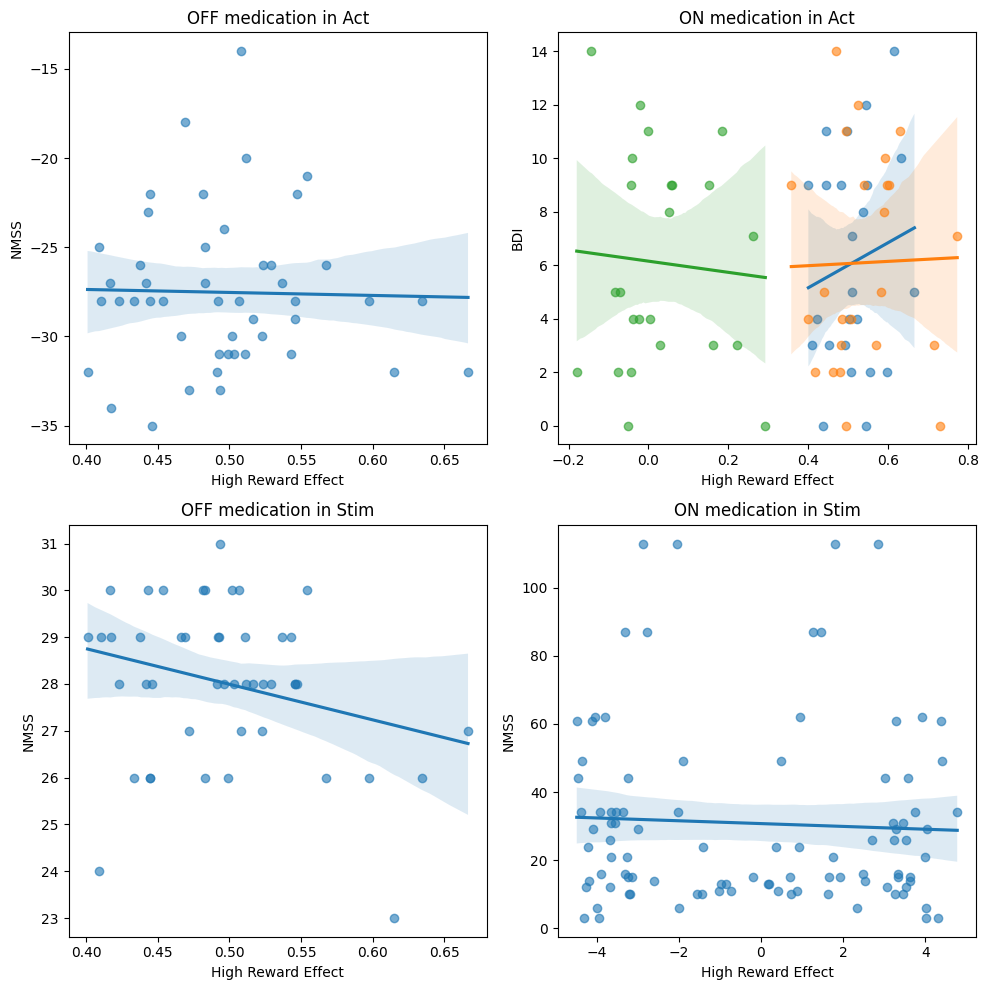

In [90]:
# pd group
df_all_PD = df_all[df_all['patient']=='PD']
df_all_PD_Act_OFF = df_all_PD[(df_all_PD['block'] == 'Act') &
                              (df_all_PD['medication'] == 'OFF')]
df_all_PD_Act_ON = df_all_PD[(df_all_PD['block'] == 'Act') &
                              (df_all_PD['medication'] == 'ON')]
df_all_PD_Stim_OFF = df_all_PD[(df_all_PD['block'] == 'Stim') &
                              (df_all_PD['medication'] == 'OFF')]
df_all_PD_Stim_ON = df_all_PD[(df_all_PD['block'] == 'Stim') &
                              (df_all_PD['medication'] == 'ON')]
  
# Plot
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax=ax.flatten()
sns.regplot(data=df_all[(df_all['block'] == 'Act')& (df_all['medication'] == 'OFF')],x="irrelevantHighRewardOption",y="LARS",
            ax=ax[0],scatter_kws={"alpha": 0.6})

ax[0].set_title("OFF medication in Act")

ax[0].set_xlabel("High Reward Effect")
ax[0].set_ylabel("NMSS")

sns.regplot(data=df_all[(df_all['block'] == 'Act')& (df_all['patient'] == 'PD')& (df_all['medication'] == 'OFF')],x="irrelevantHighRewardOption",y="BDI",
            ax=ax[1],scatter_kws={"alpha": 0.6})
sns.regplot(data=df_all[(df_all['block'] == 'Act')& (df_all['patient'] == 'PD')& (df_all['medication'] == 'OFF')],x="relevantHighRewardOption",y="BDI",
            ax=ax[1],scatter_kws={"alpha": 0.6})
sns.regplot(data=df_all[(df_all['block'] == 'Act')& (df_all['patient'] == 'PD')& (df_all['medication'] == 'OFF')],x="relevantVrIrrelevantHighRewardOption",y="BDI",
            ax=ax[1],scatter_kws={"alpha": 0.6})
ax[1].set_title("ON medication in Act")
ax[1].set_xlabel("High Reward Effect")
ax[1].set_ylabel("BDI")


sns.regplot(data=df_all[(df_all['block'] == 'Act')& (df_all['medication'] == 'OFF')],x="irrelevantHighRewardOption",y="MoCA",
            ax=ax[2],scatter_kws={"alpha": 0.6})
ax[2].set_title("OFF medication in Stim")
ax[2].set_xlabel("High Reward Effect")
ax[2].set_ylabel("NMSS")

sns.regplot(data=df_all,x="weight_parameter_mean",y="NMSS",
            ax=ax[3],scatter_kws={"alpha": 0.6})
ax[3].set_title("ON medication in Stim")
ax[3].set_xlabel("High Reward Effect")
ax[3].set_ylabel("NMSS")

plt.tight_layout()
plt.show()